In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#for statstics:
from scipy.stats import ttest_rel
import statsmodels.formula.api as smf
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
# Read data
df= pd.read_csv("dataset/experimentdata.csv")


In [ ]:
print(df.head())

   phase1_Attencheck  Q8                                                Q81  \
0                  1   1  I was given far more work, while Mark was give...   
1                  2   1  Why would it be fair that only I got extra wor...   
2                  2   3       Assigning more extra work is not justifiable   
3                  2   2        I was given more work than the other person   
4                  2   2  I chose very unfair because in phase 1 the rob...   

   Q82_1  Q73_1  Q73_2  Q73_3  Q73_4  Q73_5  Q73_6  ...  Q76_2  Q76_3  Q76_4  \
0     10      5      3      1      1      2      5  ...      5      5      2   
1      2      5      4      2      1      2      4  ...      3      4      2   
2      0      8      8      8      8      8      8  ...      5      5      2   
3      0      6      5      1      1      1      5  ...      4      4      2   
4      4      4      6      1      1      2      4  ...      5      2      2   

   Q76_5  Q78  Q79  Q79_5_TEXT  Q8.1  scenar

In [ ]:
new_column_names = ["duration",
    "fact1", "Fair1", 'Fair1_open', 'Blame1', 'ptrust1_1', 'ptrust1_2', 'mtrust1_1', 'mtrust1_2','mtrust1_3', 'ptrust1_3', 'ptrust1_4','mtrust1_4', 'mtrust1_5', 'mtrust1_6',
    'agency1_1', 'att1', 'agency1_2', 'agency1_3', 'agency1_4',
     'time1', 'time2', 'time3', 'time4',
    "fact2", "Fair2", "Fair2_open", "Blame2", 'ptrust2_1', 'ptrust2_2', 'mtrust2_1', 'mtrust2_2','mtrust2_3', 'ptrust2_3', 'ptrust2_4', 'mtrust2_4', 'mtrust2_5', 'mtrust2_6',
    'agency2_1',  'agency2_2', 'agency2_3', 'att2', 'agency2_4',
     'age', 'gender', 'gender_text', 'edu',
    "scenarioID"]

df.columns = new_column_names
print(df.head())


   fact1  Fair1                                         Fair1_open  Blame1  \
0      1      1  I was given far more work, while Mark was give...      10   
1      2      1  Why would it be fair that only I got extra wor...       2   
2      2      3       Assigning more extra work is not justifiable       0   
3      2      2        I was given more work than the other person       0   
4      2      2  I chose very unfair because in phase 1 the rob...       4   

   ptrust1_1  ptrust1_2  mtrust1_1  mtrust1_2  mtrust1_3  ptrust1_3  ...  \
0          5          3          1          1          2          5  ...   
1          5          4          2          1          2          4  ...   
2          8          8          8          8          8          8  ...   
3          6          5          1          1          1          5  ...   
4          4          6          1          1          2          4  ...   

   agency2_2  agency2_3  att2  agency2_4  age  gender  gender_text  edu  \

In [ ]:
df['scenarioID'] = df['scenarioID'].astype(str).str.strip()

In [ ]:
scenario_names = ['Work: High PA + High PA', 'Work: High PA + Low PA', 'Work: Low PA + High PA', 'Work: LoW PA + Low PA', 'Game: High PA + High PA', 'Game High PA + Low PA', 'Game: Low PA + High PA', 'Game Low PA + Low PA',]
scenario_map = {
    '1A': 'Work: High PA + High PA',
    '1B': 'Work: High PA + Low PA',
    '2A': 'Work: Low PA + High PA',
    '2B': 'Work: Low PA + Low PA',
    '7A': 'Game: High PA + High PA',
    '7B': 'Game: High PA + Low PA',
    '8A': 'Game: Low PA + High PA',
    '8B': 'Game: Low PA + Low PA'
}
df['scenario_names'] = df['scenarioID'].map(scenario_map)

In [ ]:
scenario_name_map = {
    '1A': 'Work: High PA + High PA',
    '1B': 'Work: High PA + High PA',
    '2A': 'Work: High PA + Low PA',
    '2B': 'Work: Low PA + High PA',
    '7A': 'Game: High PA + High PA',
    '7B': 'Game: High PA + High PA',
    '8A': 'Game: High PA + Low PA',
    '8B': 'Game: Low PA + High PA'
}

df['scenario_name'] = df['scenarioID'].map(scenario_name_map)

In [ ]:
# Cateogrized responses based on whether high/low agency in phase 1 and phase 2

#if a person read the high agency in phase 1, they is coded as 1, others as 0.
df['High_PA_1'] = 0
df.loc[df['scenarioID'].str.contains('1|7'), 'High_PA_1'] = 1

df['High_PA_2'] = 0
df.loc[df['scenarioID'].str.contains('A'), 'High_PA_2'] = 1

print(df.head())

   fact1  Fair1                                         Fair1_open  Blame1  \
0      1      1  I was given far more work, while Mark was give...      10   
1      2      1  Why would it be fair that only I got extra wor...       2   
2      2      3       Assigning more extra work is not justifiable       0   
3      2      2        I was given more work than the other person       0   
4      2      2  I chose very unfair because in phase 1 the rob...       4   

   ptrust1_1  ptrust1_2  mtrust1_1  mtrust1_2  mtrust1_3  ptrust1_3  ...  age  \
0          5          3          1          1          2          5  ...   29   
1          5          4          2          1          2          4  ...   50   
2          8          8          8          8          8          8  ...   26   
3          6          5          1          1          1          5  ...   46   
4          4          6          1          1          2          4  ...   38   

   gender  gender_text  edu  scenarioID  dur

In [ ]:
df['scenarioID'] = df['scenarioID'].astype(str).str.strip()
print(df['scenarioID'].unique())

['1A' '2A' '2B' '1B']


In [ ]:
work_scenarios = ['1A', '1B', '2A', '2B']
game_scenarios = ['7A', '7B', '8A', '8B']

df['Context'] = df['scenarioID'].apply(lambda x: 1 if x in work_scenarios else 2 if x in game_scenarios else np.nan)

In [ ]:
# filtering out based on the attention checks
orginal_len1 = len(df)

df=df[df['att1']==4]
df=df[df['att2']==2]


filtered_out1 = orginal_len1 - len(df)
print(f"Filtered out {filtered_out1} rows")

Filtered out 1 rows


In [ ]:
original_len2 = len(df)

df = df[
    (
        ((df['High_PA_1'] == 1) & (df['fact1'] == 1)) |
        ((df['High_PA_1'] == 0) & (df['fact1'] == 2))
    ) &
    (
        ((df['High_PA_2'] == 1) & (df['fact2'] == 2)) |
        ((df['High_PA_2'] == 0) & (df['fact2'] == 1))
    )
]

filtered_out2 = original_len2 - len(df)
print(f"Filtered out {filtered_out2} rows")



Filtered out 10 rows


In [ ]:
agency1_cols = ["agency1_1","agency1_2", "agency1_3", "agency1_4"]
agency2_cols = ["agency2_1","agency2_2", "agency2_3", "agency2_4"]
df['agency1'] = df[agency1_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
df['agency2'] = df[agency2_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)


In [ ]:
df = df.sort_values(by='scenarioID')
df['scenarioID'].value_counts()

,count
scenarioID,
2B,35
1A,32
1B,31
2A,31


In [ ]:
list(df.columns)


['fact1',
 'Fair1',
 'Fair1_open',
 'Blame1',
 'ptrust1_1',
 'ptrust1_2',
 'mtrust1_1',
 'mtrust1_2',
 'mtrust1_3',
 'ptrust1_3',
 'ptrust1_4',
 'mtrust1_4',
 'mtrust1_5',
 'mtrust1_6',
 'agency1_1',
 'att1',
 'agency1_2',
 'agency1_3',
 'agency1_4',
 'time1',
 'time2',
 'time3',
 'time4',
 'fact2',
 'Fair2',
 'Fair2_open',
 'Blame2',
 'ptrust2_1',
 'ptrust2_2',
 'mtrust2_1',
 'mtrust2_2',
 'mtrust2_3',
 'ptrust2_3',
 'ptrust2_4',
 'mtrust2_4',
 'mtrust2_5',
 'mtrust2_6',
 'agency2_1',
 'agency2_2',
 'agency2_3',
 'att2',
 'agency2_4',
 'age',
 'gender',
 'gender_text',
 'edu',
 'scenarioID',
 'duration',
 'scenario_names',
 'scenario_name',
 'High_PA_1',
 'High_PA_2',
 'Context',
 'agency1',
 'agency2']

In [ ]:
len(df)

129

In [ ]:
#trust missing value
cols = [
    'ptrust1_1', 'ptrust1_2', 'mtrust1_1', 'mtrust1_2', 'mtrust1_3',
    'ptrust1_3', 'ptrust1_4', 'mtrust1_4', 'mtrust1_5', 'mtrust1_6', 'ptrust2_1',
 'ptrust2_2',
 'mtrust2_1',
 'mtrust2_2',
 'mtrust2_3',
 'ptrust2_3',
 'ptrust2_4',
 'mtrust2_4',
 'mtrust2_5',
 'mtrust2_6',
]


df[cols] = df[cols].replace(9, np.nan)


In [ ]:
df['PerTrust1'] = df[['ptrust1_1', 'ptrust1_2', 'ptrust1_3', 'ptrust1_4']].mean(axis=1)
df['PerTrust2'] = df[['ptrust2_1', 'ptrust2_2', 'ptrust2_3', 'ptrust2_4']].mean(axis=1)
df['MoralTrust1'] = df[['mtrust1_1', 'mtrust1_2', 'mtrust1_3', 'mtrust1_4', 'mtrust1_5', 'mtrust1_6']].mean(axis=1)
df['MoralTrust2'] = df[['mtrust2_1', 'mtrust2_2', 'mtrust2_3', 'mtrust2_4', 'mtrust2_5', 'mtrust2_6']].mean(axis=1)

In [ ]:
df[['PerTrust1', 'PerTrust2', 'MoralTrust1', 'MoralTrust2']]

,PerTrust1,PerTrust2,MoralTrust1,MoralTrust2
139,6.00,5.00,5.833333,5.000000
98,6.00,5.00,4.000000,3.166667
54,5.75,6.75,6.333333,6.666667
31,6.50,4.75,6.500000,3.000000
32,4.50,5.00,2.666667,2.166667
...,...,...,...,...
73,5.50,5.00,5.000000,5.000000
71,3.00,2.75,3.166667,2.500000
86,4.50,4.00,5.333333,4.000000
23,4.75,4.75,1.500000,2.000000


In [ ]:
df['PerTrust1'].isna().sum()


np.int64(0)

In [ ]:
df['PerTrust2'].isna().sum()

np.int64(0)

In [ ]:
df['gender'].value_counts()

,count
gender,
1,66
2,63


In [ ]:
df['age'].mean()

np.float64(39.06201550387597)

In [ ]:
df['MoralTrust1'].isna().sum()


np.int64(5)

In [ ]:
df['MoralTrust2'].isna().sum()

np.int64(2)

In [ ]:
#create subject ID
df['SubjectID'] = range(1, len(df) + 1)

In [ ]:
# df_long = pd.read_csv("df_long.csv")
# df=pd.read_csv("df.csv")

In [ ]:
conditions = [
    (df['High_PA_1'] == 1) & (df['High_PA_2'] == 1),
    (df['High_PA_1'] == 1) & (df['High_PA_2'] == 0),
    (df['High_PA_1'] == 0) & (df['High_PA_2'] == 1),
    (df['High_PA_1'] == 0) & (df['High_PA_2'] == 0)
]

choices1 = ['High_High', 'High_Low', 'Low_High', 'Low_Low']
choices2 = [0, 1, 1, 0]


df['Group4'] = np.select(conditions, choices1, default='Unknown')
df['Dynamic'] = np.select(conditions, choices2)

In [ ]:
df["Group4"].value_counts().sort_index()

,count
Group4,
High_High,32
High_Low,31
Low_High,31
Low_Low,35


In [ ]:
def plot_histograms_with_mean(df, variable1, variable2=None, group_col=None, title='', xlim=(1, 5), ylim=(0, 6)):
    """
    Plots histograms of one or two variables grouped by group_col, with red lines for the mean.

    Parameters:
        df (pd.DataFrame): DataFrame with the data.
        variable1 (str): First variable to plot (mandatory).
        variable2 (str or None): Second variable to plot (optional).
        group_col (str): Grouping column name.
        title (str): Title prefix for subplots.
        xlim (tuple): X-axis limits.
        ylim (tuple): Y-axis limits.
    """
    groups = df[group_col].unique()
    n_groups = len(groups)

    n_cols = min(n_groups, 4)
    n_rows = 2 if variable2 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)

    # Normalize axes to always be 2D for uniform indexing
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, sid in enumerate(groups):
        df_subset = df[df[group_col] == sid]

        # Row 0: variable1
        var1_data = df_subset[variable1].dropna()
        axes[0, i].hist(var1_data, bins=10, color='skyblue', edgecolor='black')
        axes[0, i].axvline(var1_data.mean(), color='red', linestyle='--', linewidth=2)
        axes[0, i].text(var1_data.mean(), ylim[1] * 0.9, f'Mean: {var1_data.mean():.2f}', color='red', ha='center')
        axes[0, i].set_title(f'{group_col} {sid} - {title} (Phase 1)')
        axes[0, i].set_xlim(xlim)
        axes[0, i].set_ylim(ylim)

        # Row 1: variable2, only if given
        if variable2:
            var2_data = df_subset[variable2].dropna()
            axes[1, i].hist(var2_data, bins=10, color='lightgreen', edgecolor='black')
            axes[1, i].axvline(var2_data.mean(), color='red', linestyle='--', linewidth=2)
            axes[1, i].text(var2_data.mean(), ylim[1] * 0.9, f'Mean: {var2_data.mean():.2f}', color='red', ha='center')
            axes[1, i].set_title(f'{group_col} {sid} - {title} (Phase 2)')
            axes[1, i].set_xlim(xlim)
            axes[1, i].set_ylim(ylim)

    # Hide unused axes if any
    for j in range(i + 1, n_cols):
        axes[0, j].axis('off')
        if variable2:
            axes[1, j].axis('off')

    plt.tight_layout()
    plt.show()

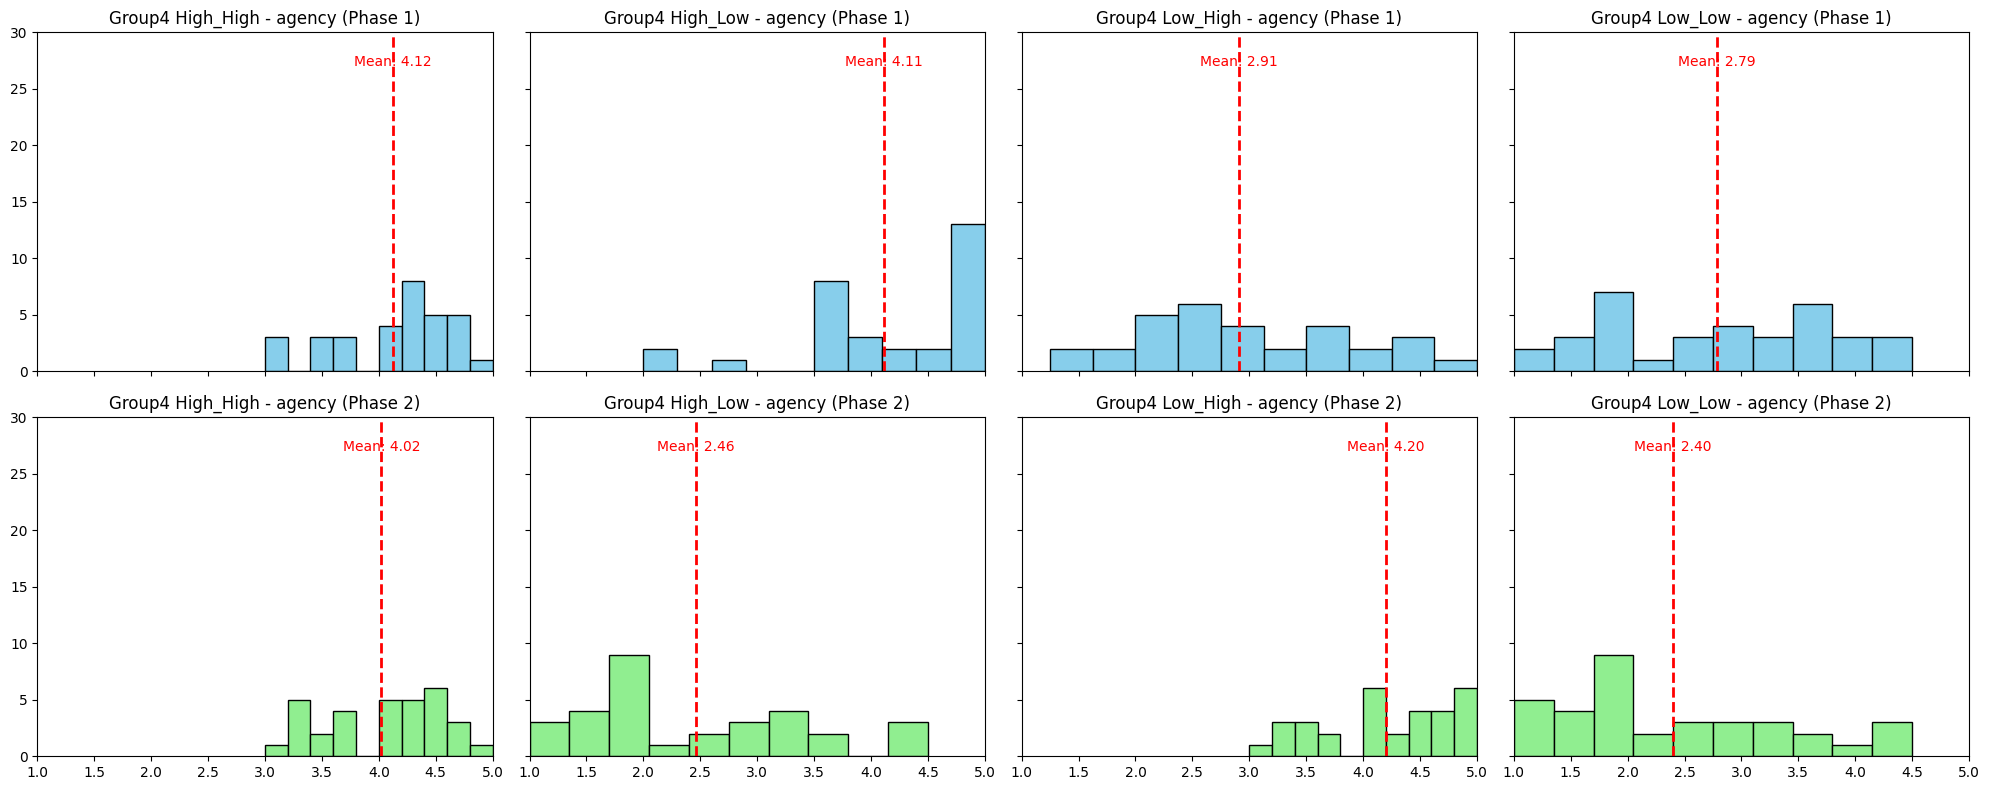

In [ ]:
plot_histograms_with_mean(df,'agency1', 'agency2','Group4', "agency", xlim=(1,5), ylim=(0,30))

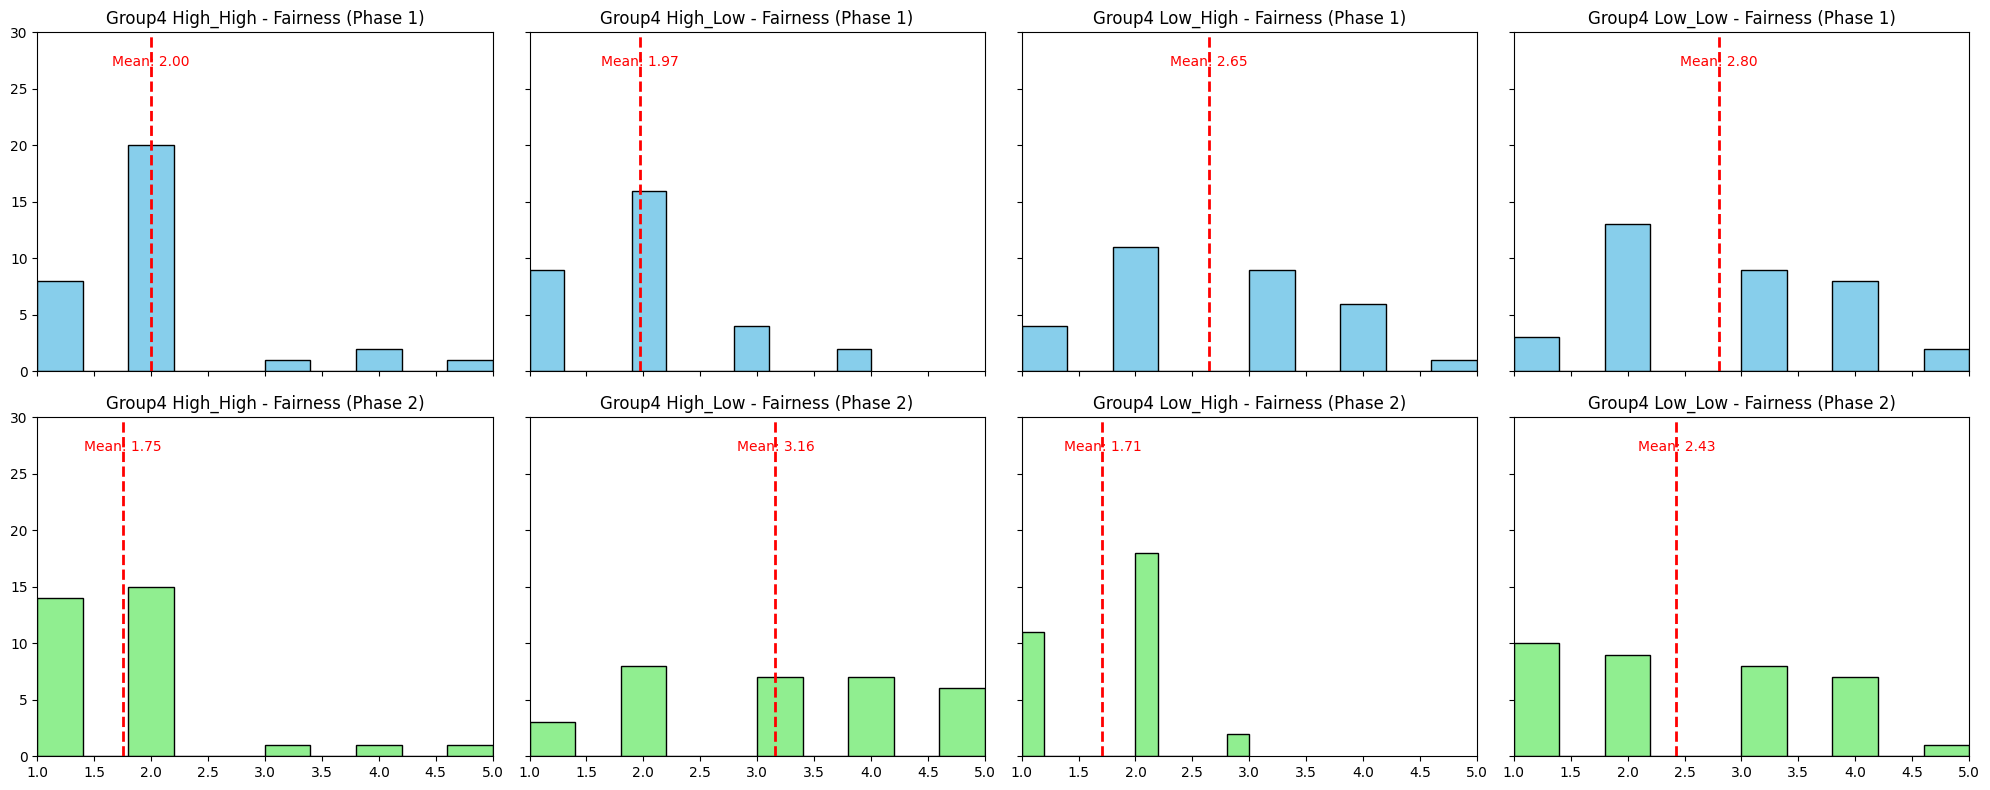

In [ ]:
plot_histograms_with_mean(df,'Fair1', 'Fair2','Group4', "Fairness", xlim=(1,5), ylim=(0,30))

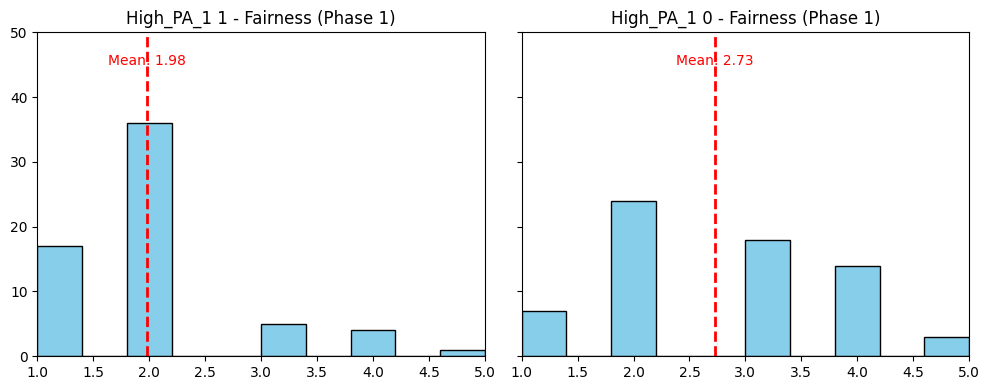

In [ ]:
plot_histograms_with_mean(df,'Fair1', None, 'High_PA_1', "Fairness", xlim=(1,5), ylim=(0,50))

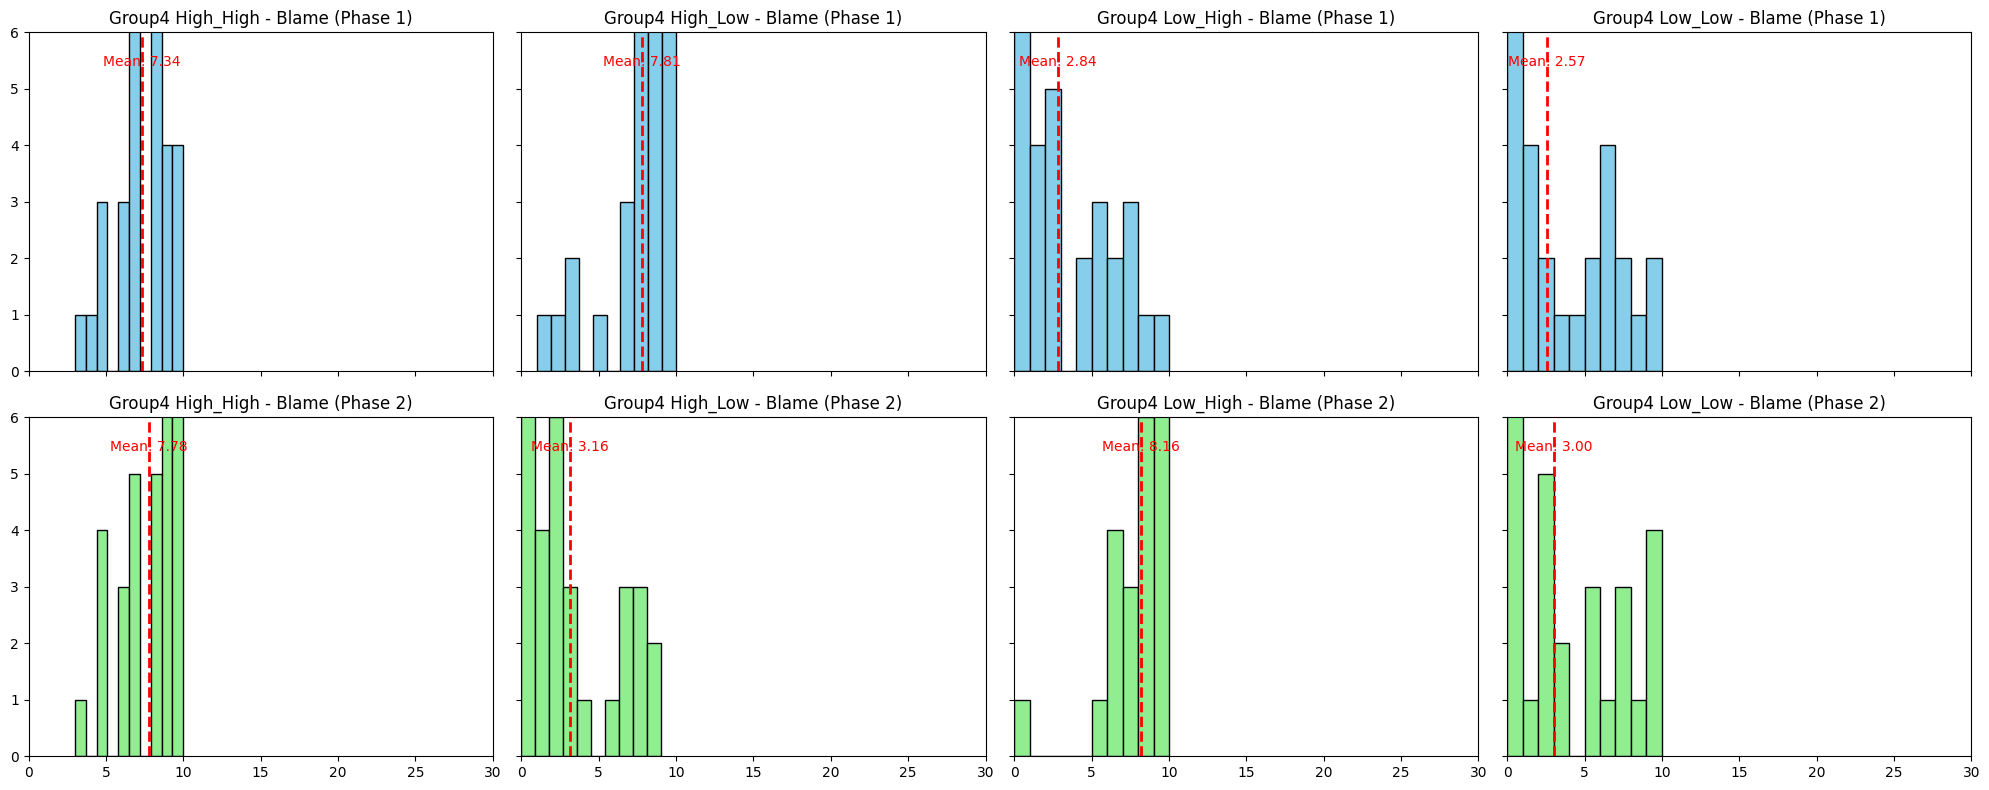

In [ ]:
plot_histograms_with_mean(df,'Blame1', 'Blame2', 'Group4', "Blame", xlim=(0,30), ylim=(0,6))

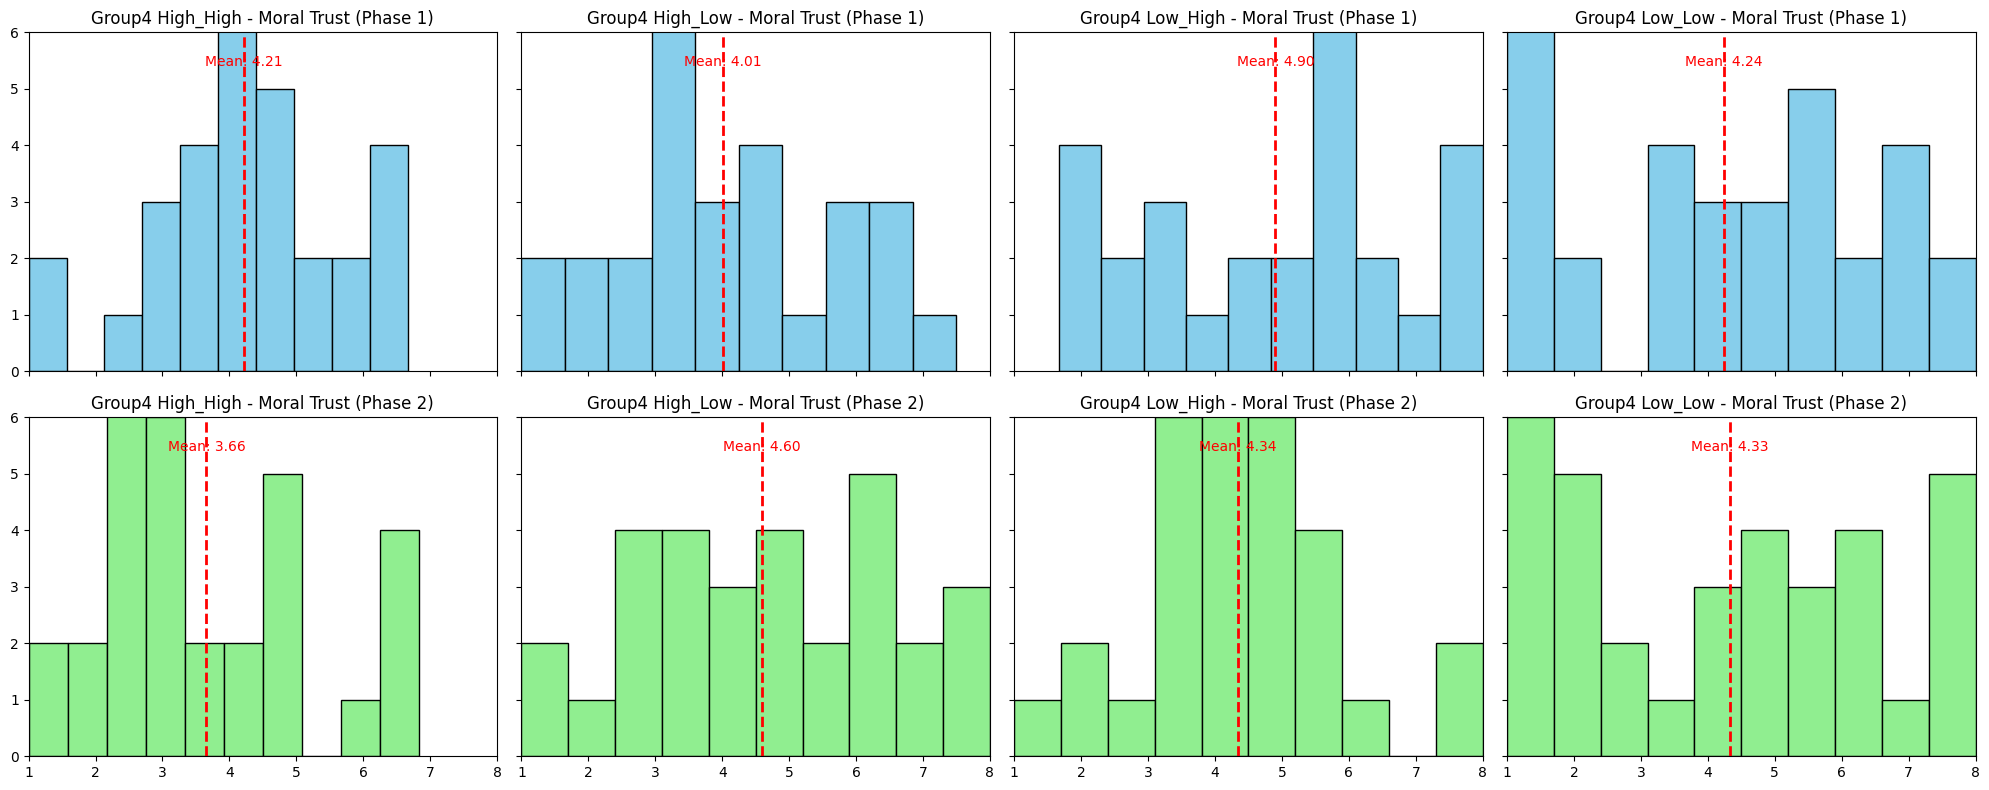

In [ ]:
plot_histograms_with_mean(df,'MoralTrust1', 'MoralTrust2','Group4', "Moral Trust", xlim=(1,8), ylim=(0,6))

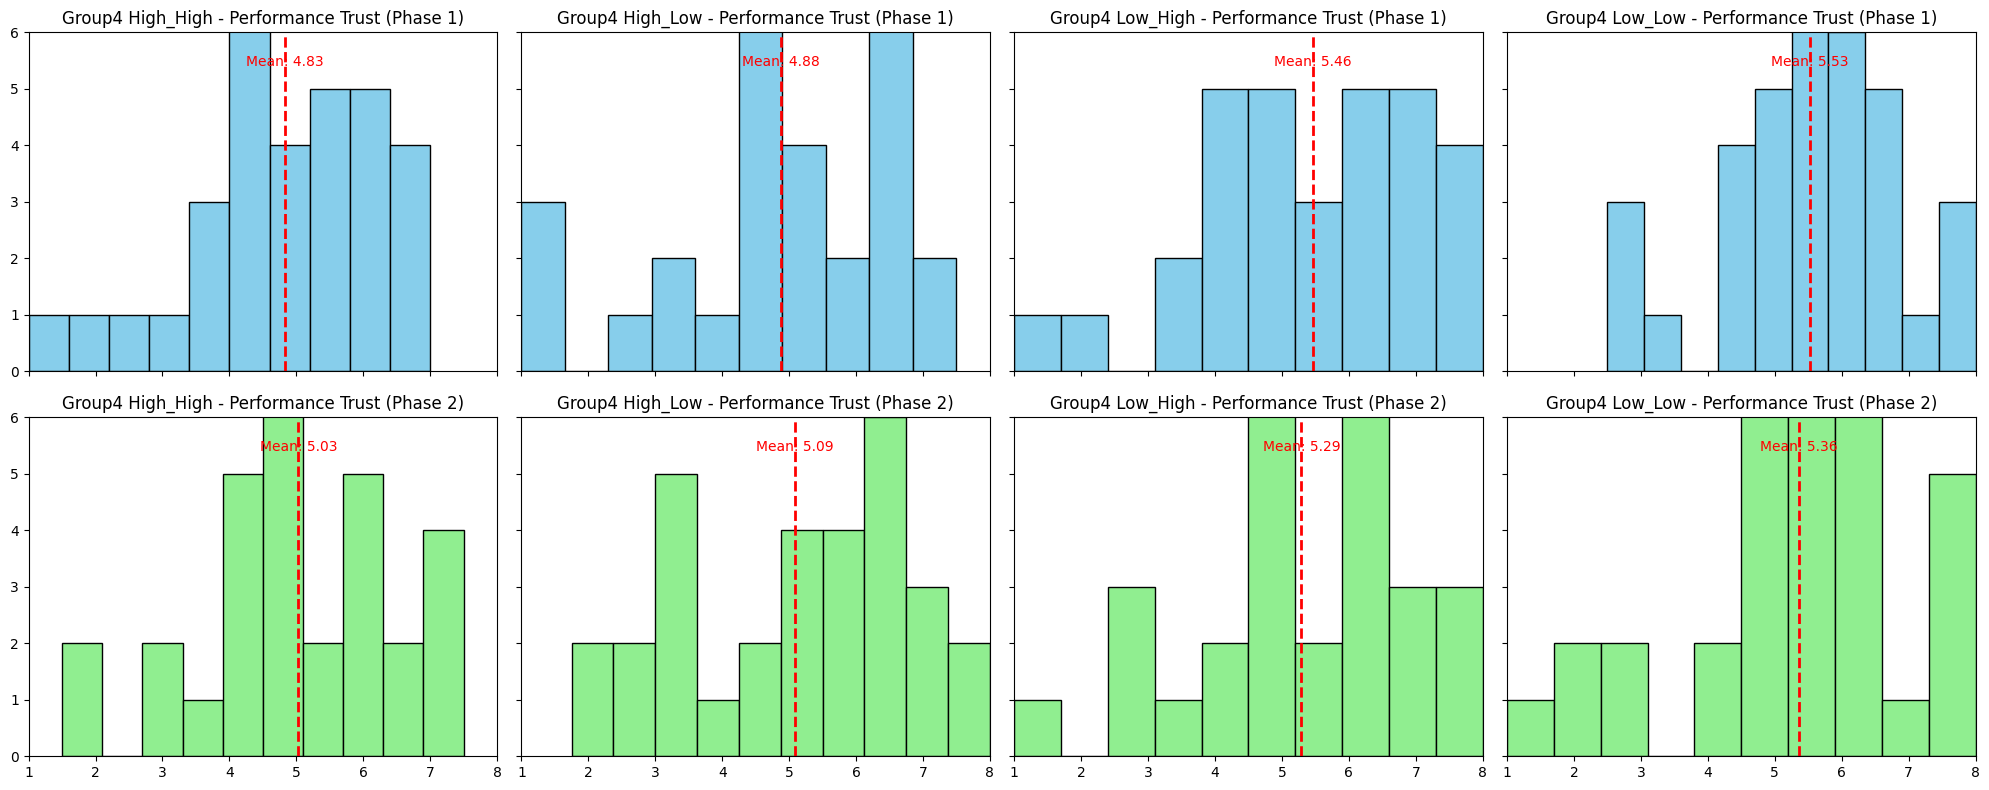

In [ ]:
plot_histograms_with_mean(df,'PerTrust1', 'PerTrust2','Group4', "Performance Trust", xlim=(1,8), ylim=(0,6))

# Data Struction Formation
Since it’s a mixed between- and within-subjects design, we need to restructure the data format as below:
A: starting with High Agency
B: starting with Low Agency


| Subject | Group | Phase  | Score |
|---------|-------|--------|-------|
| 1       | A     | Phase1 | 5.2   |
| 1       | A     | Phase2 | 6.8   |
| 2       | B     | Phase1 | 4.9   |
| 2       | B     | Phase2 | 5.4   |
| …       | …     | …      | …     |

In [ ]:
df.columns

Index(['fact1', 'Fair1', 'Fair1_open', 'Blame1', 'ptrust1_1', 'ptrust1_2',
       'mtrust1_1', 'mtrust1_2', 'mtrust1_3', 'ptrust1_3', 'ptrust1_4',
       'mtrust1_4', 'mtrust1_5', 'mtrust1_6', 'agency1_1', 'att1', 'agency1_2',
       'agency1_3', 'agency1_4', 'time1', 'time2', 'time3', 'time4', 'fact2',
       'Fair2', 'Fair2_open', 'Blame2', 'ptrust2_1', 'ptrust2_2', 'mtrust2_1',
       'mtrust2_2', 'mtrust2_3', 'ptrust2_3', 'ptrust2_4', 'mtrust2_4',
       'mtrust2_5', 'mtrust2_6', 'agency2_1', 'agency2_2', 'agency2_3', 'att2',
       'agency2_4', 'age', 'gender', 'gender_text', 'edu', 'scenarioID',
       'duration', 'scenario_names', 'scenario_name', 'High_PA_1', 'High_PA_2',
       'Context', 'agency1', 'agency2', 'PerTrust1', 'PerTrust2',
       'MoralTrust1', 'MoralTrust2', 'SubjectID', 'Group4', 'Dynamic'],
      dtype='object')

In [ ]:
# Using the melted function: 'Fair1', 'Fair2', 'trust1', 'trust2', 'agency1', 'agency2 will be one column.
df_melted = pd.melt(
    df,
    id_vars=['SubjectID', 'Group4', 'Dynamic'],
    value_vars=['Fair1', 'Fair2', 'agency1', 'agency2', 'Blame1', 'Blame2', 'PerTrust1', 'PerTrust2', 'MoralTrust1', 'MoralTrust2', 'High_PA_1', 'High_PA_2'],
    var_name='Measure',
    value_name='Score'
)
df_melted["Measure"].value_counts()

,count
Measure,
Fair1,129
Fair2,129
agency1,129
agency2,129
Blame1,129
Blame2,129
PerTrust1,129
PerTrust2,129
MoralTrust1,129


In [ ]:
# Extract Phase and Variable type from column names
df_melted['Phase'] = df_melted['Measure'].str[-1].astype(int).map({1: 0, 2: 1})
df_melted['Variable'] = df_melted['Measure'].str[:-1]
df_melted['Variable'].value_counts()



,count
Variable,
Fair,258
agency,258
Blame,258
PerTrust,258
MoralTrust,258
High_PA_,258


In [ ]:
# Pivot the data to get columns back for each variable
df_long = df_melted.pivot_table(
    index=['SubjectID', 'Group4', 'Phase', 'Dynamic'],
    columns='Variable',
    values='Score'
).reset_index()


In [ ]:
df_long

Variable,SubjectID,Group4,Phase,Dynamic,Blame,Fair,High_PA_,MoralTrust,PerTrust,agency,Phase_group
0,1,High_High,0,0,8.0,2.0,1.0,5.833333,6.00,4.50,0
1,1,High_High,1,0,6.0,2.0,1.0,5.000000,5.00,4.25,1
2,2,High_High,0,0,6.0,2.0,1.0,4.000000,6.00,4.00,0
3,2,High_High,1,0,6.0,2.0,1.0,3.166667,5.00,4.00,1
4,3,High_High,0,0,7.0,2.0,1.0,6.333333,5.75,3.75,0
...,...,...,...,...,...,...,...,...,...,...,...
253,127,Low_Low,1,0,6.0,2.0,0.0,4.000000,4.00,3.00,1
254,128,Low_Low,0,0,0.0,2.0,0.0,1.500000,4.75,4.50,0
255,128,Low_Low,1,0,2.0,1.0,0.0,2.000000,4.75,1.50,1
256,129,Low_Low,0,0,2.0,3.0,0.0,1.166667,4.25,1.75,0


# Manipulation Check
	* Statistically testing whether the four groups differ based on group assignment.
	* For Phase 1, an independent-samples t-test can be used.
	* For Phase 2, a mixed-design ANOVA is used to examine the interaction between phase and group.  



### PA Scores

/tmp/ipython-input-3642909475.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
/tmp/ipython-input-3642909475.py:11: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.pointplot(


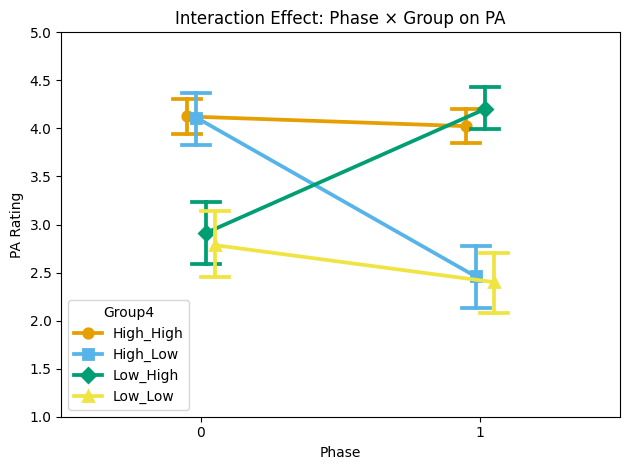

In [ ]:
# Make sure Phase and Group are treated as categorical
df_long['Phase_group'] = df_long['Phase'].astype(str)
df_long['Group4'] = df_long['Group4'].astype(str)

cb_palette = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00"]

# Define markers for each group
markers = ['o', 's', 'D', '^', 'v', 'P']  # circle, square, diamond, triangle_up, triangle_down, plus

# Create the point plot
sns.pointplot(
    data=df_long,
    x='Phase_group',
    y='agency',
    hue='Group4',
    ci=95,
    capsize=0.1,
    dodge=True,
    palette=cb_palette,
    markers=markers
)

# Fix axis labels
plt.title('Interaction Effect: Phase × Group on PA')
plt.xlabel('Phase')
plt.ylabel('PA Rating')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

In [ ]:
# Collapsed phases

group_means = df_long.groupby('High_PA_')['agency'].mean()
group_stats = df_long.groupby('High_PA_')['agency'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print(group_means)
print(group_stats)
# Example: DV = 'agency', IV = 'Group'
high_agency = df_long[df_long['High_PA_'] == 1]['agency']
low_agency = df_long[df_long['High_PA_'] == 0]['agency']

f_stat, p_val = f_oneway(high_agency, low_agency)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

n_high = len(high_agency)
n_low = len(low_agency)
df_between = 1
df_within = n_high + n_low - 2

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")
# Filter Phase 1 only
df_posthoc = df_long

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['agency'],
                          groups=df_posthoc['High_PA_'],
                          alpha=0.05)

# Print results
print(tukey)

High_PA_
0.0    2.636364
1.0    4.115079
Name: agency, dtype: float64
              mean       std  count        se
High_PA_                                     
0.0       2.636364  1.003982    132  0.087385
1.0       4.115079  0.632970    126  0.056389
F = 198.135, p = 0.000
F(1, 256) = 198.135, p = 0.000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   0.0    1.0   1.4787   0.0 1.2718 1.6856   True
-------------------------------------------------


In [ ]:
#ANOVA in phase 1

group_means1 = df.groupby('High_PA_1')['agency1'].mean()
group_stats1 = df.groupby('High_PA_1')['agency1'].agg(['mean', 'std', 'count'])
group_stats1['se'] = group_stats1['std'] / np.sqrt(group_stats1['count'])

print(group_means1)
print(group_stats1)

high_agency = df[df['High_PA_1'] == 1]['agency1']
low_agency = df[df['High_PA_1'] == 0]['agency1']

n_high = len(high_agency)
n_low = len(low_agency)
df_between = 1
df_within = n_high + n_low - 2

f_stat, p_val = f_oneway(high_agency, low_agency)

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

High_PA_1
0    2.844697
1    4.119048
Name: agency1, dtype: float64
               mean       std  count        se
High_PA_1                                     
0          2.844697  0.993987     66  0.122351
1          4.119048  0.682230     63  0.085953
F(1, 127) = 71.422, p = 0.000


In [ ]:
#phase1 for agency

group1 = df[df['Group4'] == 'High_High']['agency1']
group2 = df[df['Group4'] == 'High_Low']['agency1']
group3 = df[df['Group4'] == 'Low_High']['agency1']
group4 = df[df['Group4'] == 'Low_Low']['agency1']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['agency1'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

F(3, 125) = 23.616, p = 0.000

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  4.125000  0.095250
High_Low   4.112903  0.146114
Low_High   2.911290  0.175268
Low_Low    2.785714  0.172458


In [ ]:
#phase2 for agency

group1 = df[df['Group4'] == 'High_High']['agency2']
group2 = df[df['Group4'] == 'High_Low']['agency2']
group3 = df[df['Group4'] == 'Low_High']['agency2']
group4 = df[df['Group4'] == 'Low_Low']['agency2']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['agency2'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])


F(3, 125) = 46.251, p = 0.000

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  4.023438  0.095488
High_Low   2.459677  0.172776
Low_High   4.201613  0.112055
Low_Low    2.400000  0.169713


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['agency2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low  -1.5638    0.0 -2.0977 -1.0298   True
High_High Low_High   0.1782 0.8209 -0.3558  0.7121  False
High_High  Low_Low  -1.6234    0.0 -2.1417 -1.1052   True
 High_Low Low_High   1.7419    0.0  1.2038  2.2801   True
 High_Low  Low_Low  -0.0597 0.9908 -0.5822  0.4629  False
 Low_High  Low_Low  -1.8016    0.0 -2.3242  -1.279   True
---------------------------------------------------------


In [ ]:
df_long['Phase'] = df_long['Phase'].astype('category')
df_long['Group4'] = df_long['Group4'].astype('category')

# Linear Mixed Model
model = smf.mixedlm("agency ~ Phase * Group4", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      agency   
No. Observations:        258          Method:                  REML     
No. Groups:              129          Scale:                   0.4875   
Min. group size:         2            Log-Likelihood:          -318.3106
Max. group size:         2            Converged:               Yes      
Mean group size:         2.0                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      4.125    0.148 27.844 0.000  3.835  4.415
Phase[T.1]                    -0.102    0.175 -0.582 0.561 -0.444  0.241
Group4[T.High_Low]            -0.012    0.211 -0.057 0.954 -0.426  0.402
Group4[T.Low_High]            -1.214    0.211 -5.747 0.000 -1.628 -0.

In [ ]:
# Linear Mixed Model
model = smf.mixedlm("agency ~ Phase * High_PA_", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   agency   
No. Observations:    258       Method:               REML     
No. Groups:          129       Scale:                0.4819   
Min. group size:     2         Log-Likelihood:       -316.1838
Max. group size:     2         Converged:            Yes      
Mean group size:     2.0                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            2.836    0.100 28.305 0.000  2.640  3.033
Phase[T.1]          -0.398    0.129 -3.080 0.002 -0.651 -0.145
High_PA_             1.291    0.140  9.238 0.000  1.017  1.565
Phase[T.1]:High_PA_  0.370    0.197  1.884 0.060 -0.015  0.756
Group Var            0.212    0.116                           



##Blame

/tmp/ipython-input-2576318196.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
/tmp/ipython-input-2576318196.py:2: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.pointplot(


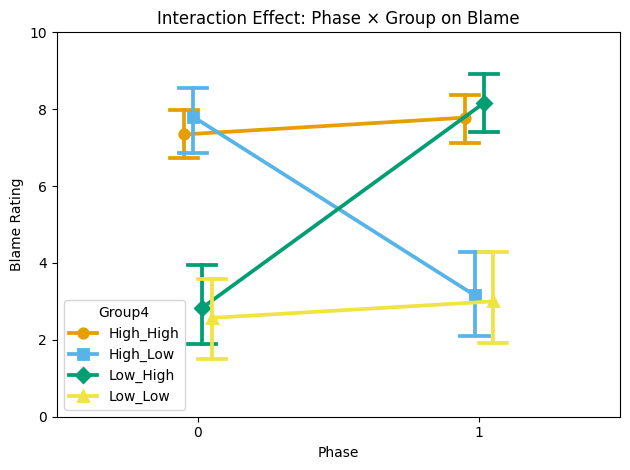

In [ ]:
# Create the point plot
sns.pointplot(
    data=df_long,
    x='Phase_group',
    y='Blame',
    hue='Group4',
    ci=95,
    capsize=0.1,
    dodge=True,
    palette=cb_palette,
    markers=markers
)

# Fix axis labels
plt.title('Interaction Effect: Phase × Group on Blame')
plt.xlabel('Phase')
plt.ylabel('Blame Rating')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

In [ ]:
#ANOVA in phase 1

group_means1 = df.groupby('High_PA_1')['Blame1'].mean()
group_stats1 = df.groupby('High_PA_1')['Blame1'].agg(['mean', 'std', 'count'])
group_stats1['se'] = group_stats1['std'] / np.sqrt(group_stats1['count'])

print(group_means1)
print(group_stats1)

high_agency = df[df['High_PA_1'] == 1]['Blame1']
low_agency = df[df['High_PA_1'] == 0]['Blame1']

n_high = len(high_agency)
n_low = len(low_agency)
df_between = 1
df_within = n_high + n_low - 2

f_stat, p_val = f_oneway(high_agency, low_agency)

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

High_PA_1
0    2.696970
1    7.571429
Name: Blame1, dtype: float64
               mean       std  count        se
High_PA_1                                     
0          2.696970  3.058253     66  0.376445
1          7.571429  2.130533     63  0.268422
F(1, 127) = 109.363, p = 0.000


In [ ]:
group1 = df[df['Group4'] == 'High_High']['Blame1']
group2 = df[df['Group4'] == 'High_Low']['Blame1']
group3 = df[df['Group4'] == 'Low_High']['Blame1']
group4 = df[df['Group4'] == 'Low_Low']['Blame1']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['Blame1'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

F(3, 125) = 36.279, p = 0.000

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  7.343750  0.309817
High_Low   7.806452  0.443397
Low_High   2.838710  0.532991
Low_Low    2.571429  0.536540


In [ ]:
group1 = df[df['Group4'] == 'High_High']['Blame2']
group2 = df[df['Group4'] == 'High_Low']['Blame2']
group3 = df[df['Group4'] == 'Low_High']['Blame2']
group4 = df[df['Group4'] == 'Low_Low']['Blame2']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['Blame2'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

F(3, 125) = 33.679, p = 0.000

Group Stats (Mean, SE):
              mean        se
Group4                      
High_High  7.78125  0.335213
High_Low   3.16129  0.566249
Low_High   8.16129  0.388260
Low_Low    3.00000  0.585540


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("Blame ~ Phase * Group4", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      Blame    
No. Observations:        258          Method:                  REML     
No. Groups:              129          Scale:                   4.0972   
Min. group size:         2            Log-Likelihood:          -604.5819
Max. group size:         2            Converged:               Yes      
Mean group size:         2.0                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      7.344    0.480 15.302 0.000  6.403  8.284
Phase[T.1]                     0.438    0.506  0.865 0.387 -0.554  1.429
Group4[T.High_Low]             0.463    0.684  0.676 0.499 -0.878  1.804
Group4[T.Low_High]            -4.505    0.684 -6.585 0.000 -5.846 -3.

In [ ]:
# Linear Mixed Model
model = smf.mixedlm("Blame ~ Phase * High_PA_", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Blame    
No. Observations:   258       Method:               REML     
No. Groups:         129       Scale:                4.0487   
Min. group size:    2         Log-Likelihood:       -606.9403
Max. group size:    2         Converged:            Yes      
Mean group size:    2.0                                      
-------------------------------------------------------------
                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           2.674    0.316  8.472 0.000  2.056  3.293
Phase[T.1]          0.382    0.384  0.993 0.321 -0.372  1.135
High_PA_            4.921    0.426 11.554 0.000  4.086  5.756
Phase[T.1]:High_PA_ 0.012    0.597  0.020 0.984 -1.158  1.182
Group Var           3.224    0.462                           



#Hypothesis Testing: Fairness


/tmp/ipython-input-1735188178.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
/tmp/ipython-input-1735188178.py:2: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.pointplot(


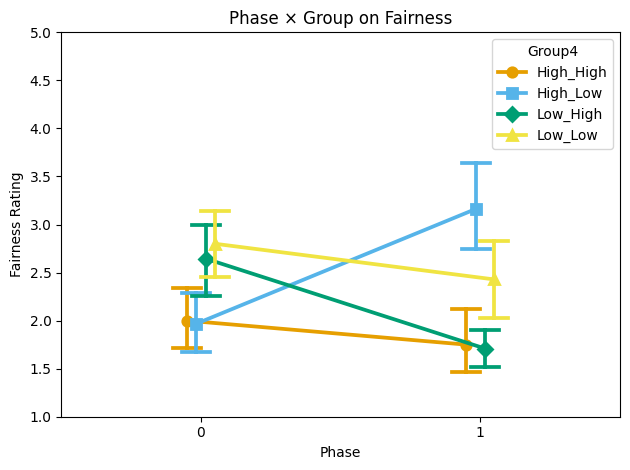

In [ ]:
# Create the point plot
sns.pointplot(
    data=df_long,
    x='Phase_group',
    y='Fair',
    hue='Group4',
    ci=95,
    capsize=0.1,
    dodge=True,
    palette=cb_palette,
    markers=markers
)

# Fix axis labels
plt.title('Phase × Group on Fairness')
plt.xlabel('Phase')
plt.ylabel('Fairness Rating')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

In [ ]:
# Collapsed phases

group_means = df_long.groupby('High_PA_')['Fair'].mean()
group_stats = df_long.groupby('High_PA_')['Fair'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print(group_means)
print(group_stats)
# Example: DV = 'agency', IV = 'Group'
high_agency = df_long[df_long['High_PA_'] == 1]['Fair']
low_agency = df_long[df_long['High_PA_'] == 0]['Fair']

f_stat, p_val = f_oneway(high_agency, low_agency)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

n_high = len(high_agency)
n_low = len(low_agency)
df_between = 1
df_within = n_high + n_low - 2

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")
# Filter Phase 1 only
df_posthoc = df_long

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Fair'],
                          groups=df_posthoc['High_PA_'],
                          alpha=0.05)

# Print results
print(tukey)

High_PA_
0.0    2.750000
1.0    1.857143
Name: Fair, dtype: float64
              mean       std  count        se
High_PA_                                     
0.0       2.750000  1.174637    132  0.102239
1.0       1.857143  0.826697    126  0.073648
F = 49.426, p = 0.000
F(1, 256) = 49.426, p = 0.000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
   0.0    1.0  -0.8929   0.0 -1.143 -0.6428   True
--------------------------------------------------


In [ ]:
#ANOVA in phase 1

group_means1 = df.groupby('High_PA_1')['Fair1'].mean()
group_stats1 = df.groupby('High_PA_1')['Fair1'].agg(['mean', 'std', 'count'])
group_stats1['se'] = group_stats1['std'] / np.sqrt(group_stats1['count'])

print(group_means1)
print(group_stats1)

high_agency = df[df['High_PA_1'] == 1]['Fair1']
low_agency = df[df['High_PA_1'] == 0]['Fair1']

n_high = len(high_agency)
n_low = len(low_agency)
df_between = 1
df_within = n_high + n_low - 2

f_stat, p_val = f_oneway(high_agency, low_agency)

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")


High_PA_1
0    2.727273
1    1.984127
Name: Fair1, dtype: float64
               mean       std  count        se
High_PA_1                                     
0          2.727273  1.060413     66  0.130528
1          1.984127  0.870522     63  0.109675
F(1, 127) = 18.828, p = 0.000


In [ ]:
#ANOVA in phase 2

group1 = df[df['Group4'] == 'High_High']['Fair1']
group2 = df[df['Group4'] == 'High_Low']['Fair1']
group3 = df[df['Group4'] == 'Low_High']['Fair1']
group4 = df[df['Group4'] == 'Low_Low']['Fair1']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['Fair1'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Fair1'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

F(3, 125) = 6.341, p = 0.000

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  2.000000  0.161894
High_Low   1.967742  0.150153
Low_High   2.645161  0.188648
Low_Low    2.800000  0.182421
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower  upper  reject
--------------------------------------------------------
High_High High_Low  -0.0323 0.9992 -0.6743 0.6098  False
High_High Low_High   0.6452 0.0484  0.0031 1.2872   True
High_High  Low_Low      0.8  0.006  0.1769 1.4231   True
 High_Low Low_High   0.6774 0.0364  0.0303 1.3245   True
 High_Low  Low_Low   0.8323 0.0042  0.2039 1.4606   True
 Low_High  Low_Low   0.1548 0.9183 -0.4735 0.7832  False
--------------------------------------------------------


In [ ]:
#ANOVA in phase 2

group1 = df[df['Group4'] == 'High_High']['Fair2']
group2 = df[df['Group4'] == 'High_Low']['Fair2']
group3 = df[df['Group4'] == 'Low_High']['Fair2']
group4 = df[df['Group4'] == 'Low_Low']['Fair2']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['Fair2'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Fair2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

F(3, 125) = 13.530, p = 0.000

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  1.750000  0.161894
High_Low   3.161290  0.232318
Low_High   1.709677  0.105683
Low_Low    2.428571  0.202031
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low   1.4113    0.0   0.729  2.0936   True
High_High Low_High  -0.0403 0.9987 -0.7227   0.642  False
High_High  Low_Low   0.6786 0.0424  0.0163  1.3408   True
 High_Low Low_High  -1.4516    0.0 -2.1393 -0.7639   True
 High_Low  Low_Low  -0.7327 0.0255 -1.4005 -0.0649   True
 Low_High  Low_Low   0.7189 0.0296  0.0511  1.3867   True
---------------------------------------------------------


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("Fair ~ Phase * Group4", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      Fair     
No. Observations:        258          Method:                  REML     
No. Groups:              129          Scale:                   0.4915   
Min. group size:         2            Log-Likelihood:          -351.5036
Max. group size:         2            Converged:               Yes      
Mean group size:         2.0                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      2.000    0.178 11.206 0.000  1.650  2.350
Phase[T.1]                    -0.250    0.175 -1.426 0.154 -0.594  0.094
Group4[T.High_Low]            -0.032    0.254 -0.127 0.899 -0.531  0.466
Group4[T.Low_High]             0.645    0.254  2.536 0.011  0.146  1.

In [ ]:
model = smf.mixedlm("Fair ~ Phase * High_PA_", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Fair     
No. Observations:    258       Method:               REML     
No. Groups:          129       Scale:                0.5152   
Min. group size:     2         Log-Likelihood:       -355.4229
Max. group size:     2         Converged:            Yes      
Mean group size:     2.0                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            2.824    0.118 23.879 0.000  2.592  3.056
Phase[T.1]          -0.065    0.139 -0.468 0.640 -0.339  0.208
High_PA_            -0.942    0.157 -5.984 0.000 -1.250 -0.633
Phase[T.1]:High_PA_ -0.073    0.219 -0.332 0.740 -0.503  0.357
Group Var            0.528    0.196                           



# Explortary: Performance Trust and Moral Trust

## Performance Trust

*   List item
*   List item



/tmp/ipython-input-3831909312.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
/tmp/ipython-input-3831909312.py:2: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.pointplot(


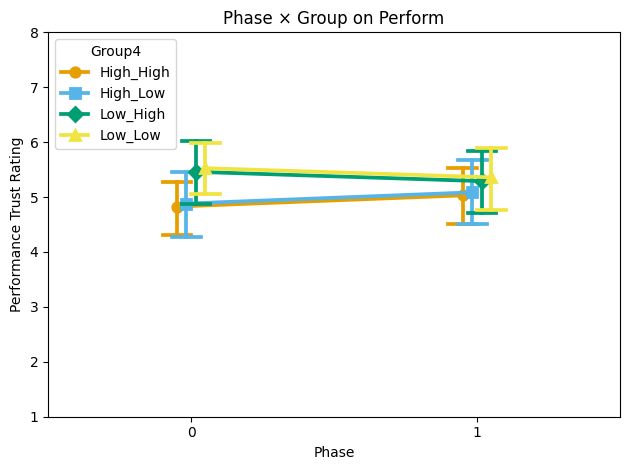

In [ ]:
# Create the point plot
sns.pointplot(
    data=df_long,
    x='Phase_group',
    y='PerTrust',
    hue='Group4',
    ci=95,
    capsize=0.1,
    dodge=True,
    palette=cb_palette,
    markers=markers
)

# Fix axis labels
plt.title('Phase × Group on Perform')
plt.xlabel('Phase')
plt.ylabel('Performance Trust Rating')
plt.ylim(1,8)
plt.tight_layout()
plt.show()

In [ ]:
#ANOVA in phase 1

group_means1 = df.groupby('High_PA_1')['PerTrust1'].mean()
group_stats1 = df.groupby('High_PA_1')['PerTrust1'].agg(['mean', 'std', 'count'])
group_stats1['se'] = group_stats1['std'] / np.sqrt(group_stats1['count'])

print(group_means1)
print(group_stats1)

high_agency = df[df['High_PA_1'] == 1]['PerTrust1']
low_agency = df[df['High_PA_1'] == 0]['PerTrust1']

n_high = len(high_agency)
n_low = len(low_agency)
df_between = 1
df_within = n_high + n_low - 2

f_stat, p_val = f_oneway(high_agency, low_agency)

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

High_PA_1
0    5.494949
1    4.854497
Name: PerTrust1, dtype: float64
               mean       std  count        se
High_PA_1                                     
0          5.494949  1.507806     66  0.185598
1          4.854497  1.566976     63  0.197420
F(1, 127) = 5.597, p = 0.020


In [ ]:
#ANOVA in phase 2

group1 = df[df['Group4'] == 'High_High']['PerTrust2']
group2 = df[df['Group4'] == 'High_Low']['PerTrust2']
group3 = df[df['Group4'] == 'Low_High']['PerTrust2']
group4 = df[df['Group4'] == 'Low_Low']['PerTrust2']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df.groupby('Group4')['PerTrust2'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['PerTrust2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

F(3, 125) = 0.296, p = 0.828

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  5.031250  0.262958
High_Low   5.086022  0.309437
Low_High   5.290323  0.293087
Low_Low    5.359524  0.301525
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower  upper  reject
--------------------------------------------------------
High_High High_Low   0.0548 0.9992 -1.0365 1.1461  False
High_High Low_High   0.2591 0.9261 -0.8322 1.3504  False
High_High  Low_Low   0.3283  0.851 -0.7309 1.3874  False
 High_Low Low_High   0.2043 0.9626 -0.8956 1.3042  False
 High_Low  Low_Low   0.2735 0.9094 -0.7946 1.3416  False
 Low_High  Low_Low   0.0692 0.9983 -0.9989 1.1373  False
--------------------------------------------------------


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("PerTrust~ Phase * Group4", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      PerTrust 
No. Observations:        258          Method:                  REML     
No. Groups:              129          Scale:                   1.3684   
Min. group size:         2            Log-Likelihood:          -471.6066
Max. group size:         2            Converged:               Yes      
Mean group size:         2.0                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      4.828    0.284 16.996 0.000  4.271  5.385
Phase[T.1]                     0.203    0.292  0.695 0.487 -0.370  0.776
Group4[T.High_Low]             0.054    0.405  0.132 0.895 -0.740  0.847
Group4[T.Low_High]             0.632    0.405  1.559 0.119 -0.162  1.

In [ ]:
model = smf.mixedlm("PerTrust ~ Phase * High_PA_", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   PerTrust 
No. Observations:    258       Method:               REML     
No. Groups:          129       Scale:                1.3546   
Min. group size:     2         Log-Likelihood:       -471.9581
Max. group size:     2         Converged:            Yes      
Mean group size:     2.0                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            5.434    0.186 29.226 0.000  5.069  5.798
Phase[T.1]          -0.218    0.224 -0.973 0.330 -0.656  0.221
High_PA_            -0.515    0.249 -2.068 0.039 -1.004 -0.027
Phase[T.1]:High_PA_  0.473    0.349  1.358 0.174 -0.210  1.156
Group Var            1.194    0.285                           



## Moral Trust

/tmp/ipython-input-1506724940.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
/tmp/ipython-input-1506724940.py:2: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.pointplot(


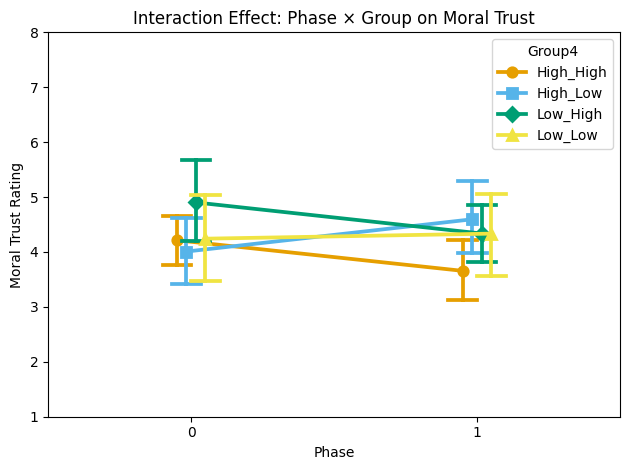

In [ ]:
# Create the point plot
sns.pointplot(
    data=df_long,
    x='Phase_group',
    y='MoralTrust',
    hue='Group4',
    ci=95,
    capsize=0.1,
    dodge=True,
    palette=cb_palette,
    markers=markers
)

# Fix axis labels
plt.title('Interaction Effect: Phase × Group on Moral Trust')
plt.xlabel('Phase')
plt.ylabel('Moral Trust Rating')
plt.ylim(1,8)
plt.tight_layout()
plt.show()

In [ ]:
df_moral = df.dropna(subset=['MoralTrust1', 'MoralTrust2'])
df_moral_long = df_long.dropna(subset=['MoralTrust'])
high_agency1 = df_moral[df_moral['High_PA_1'] == 1]['MoralTrust1']
low_agency1 = df_moral[df_moral['High_PA_1'] == 0]['MoralTrust1']

In [ ]:
#ANOVA in phase 1

group_means1 = df_moral.groupby('High_PA_1')['MoralTrust1'].mean()
group_stats1 = df_moral.groupby('High_PA_1')['MoralTrust1'].agg(['mean', 'std', 'count'])
group_stats1['se'] = group_stats1['std'] / np.sqrt(group_stats1['count'])

print(group_means1)
print(group_stats1)

# high_agency1 = df_moral[df_moral['High_PA_1'] == 1]['MoralTrust1']
# low_agency = df_moral[df_moral['High_PA_1'] == 0]['MoralTrust1']

n_high = len(high_agency1)
n_low = len(low_agency1)
df_between = 1
df_within = n_high + n_low - 2

f_stat, p_val = f_oneway(high_agency1, low_agency1)

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

High_PA_1
0    4.554167
1    4.150538
Name: MoralTrust1, dtype: float64
               mean       std  count        se
High_PA_1                                     
0          4.554167  2.146792     60  0.277150
1          4.150538  1.518169     62  0.192808
F(1, 120) = 1.445, p = 0.232


In [ ]:
#ANOVA in phase 1

group1 = df_moral[df_moral['Group4'] == 'High_High']['MoralTrust1']
group2 = df_moral[df_moral['Group4'] == 'High_Low']['MoralTrust1']
group3 = df_moral[df_moral['Group4'] == 'Low_High']['MoralTrust1']
group4 = df_moral[df_moral['Group4'] == 'Low_Low']['MoralTrust1']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df_moral.groupby('Group4')['MoralTrust1'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

# Filter Phase 1 only
df_posthoc = df_moral

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['MoralTrust1'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

F(3, 118) = 1.122, p = 0.343

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  4.213542  0.240667
High_Low   4.083333  0.308640
Low_High   4.901786  0.378184
Low_Low    4.250000  0.398389
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower  upper  reject
--------------------------------------------------------
High_High High_Low  -0.1302 0.9926 -1.3585 1.0981  False
High_High Low_High   0.6882 0.4808 -0.5625  1.939  False
High_High  Low_Low   0.0365 0.9998 -1.1719 1.2448  False
 High_Low Low_High   0.8185 0.3391 -0.4516 2.0885  False
 High_Low  Low_Low   0.1667 0.9848 -1.0616  1.395  False
 Low_High  Low_Low  -0.6518 0.5281 -1.9025  0.599  False
--------------------------------------------------------


In [ ]:
#ANOVA in phase 2

group1 = df_moral[df_moral['Group4'] == 'High_High']['MoralTrust2']
group2 = df_moral[df_moral['Group4'] == 'High_Low']['MoralTrust2']
group3 = df_moral[df_moral['Group4'] == 'Low_High']['MoralTrust2']
group4 = df_moral[df_moral['Group4'] == 'Low_Low']['MoralTrust2']

# 2. Run one-way ANOVA
f_stat, p_val = f_oneway(group1, group2, group3, group4)

# 3. Degrees of freedom
k = 4  # number of groups
n_total = len(group1) + len(group2) + len(group3) + len(group4)

df_between = k - 1
df_within = n_total - k

print(f"F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_val:.3f}")

# 4. Group means, standard errors
group_stats = df_moral.groupby('Group4')['MoralTrust2'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

print("\nGroup Stats (Mean, SE):")
print(group_stats[['mean', 'se']])

# Filter Phase 1 only
df_posthoc = df_moral

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['MoralTrust2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

F(3, 118) = 1.493, p = 0.220

Group Stats (Mean, SE):
               mean        se
Group4                       
High_High  3.656250  0.290892
High_Low   4.595556  0.346814
Low_High   4.306548  0.232921
Low_Low    4.105208  0.392001
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower  upper  reject
--------------------------------------------------------
High_High High_Low   0.9393 0.1744 -0.2523  2.131  False
High_High Low_High   0.6503  0.504 -0.5631 1.8637  False
High_High  Low_Low    0.449 0.7508 -0.7233 1.6212  False
 High_Low Low_High   -0.289 0.9283 -1.5212 0.9431  False
 High_Low  Low_Low  -0.4903  0.707  -1.682 0.7013  False
 Low_High  Low_Low  -0.2013 0.9728 -1.4148 1.0121  False
--------------------------------------------------------


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("MoralTrust~ Phase * Group4", data=df_moral_long, groups=df_moral_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      MoralTrust
No. Observations:       251          Method:                  REML      
No. Groups:             129          Scale:                   1.1145    
Min. group size:        1            Log-Likelihood:          -474.9817 
Max. group size:        2            Converged:               Yes       
Mean group size:        1.9                                             
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      4.214    0.333 12.651 0.000  3.561  4.866
Phase[T.1]                    -0.557    0.264 -2.112 0.035 -1.075 -0.040
Group4[T.High_Low]            -0.205    0.475 -0.433 0.665 -1.136  0.725
Group4[T.Low_High]             0.708    0.482  1.471 0.141 -0.235  1.

In [ ]:
model = smf.mixedlm("MoralTrust~ Phase * High_PA_", data=df_moral_long, groups=df_moral_long["SubjectID"])
result = model.fit()
print(result.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   MoralTrust
No. Observations:   251       Method:               REML      
No. Groups:         129       Scale:                1.1146    
Min. group size:    1         Log-Likelihood:       -477.2727 
Max. group size:    2         Converged:            Yes       
Mean group size:    1.9                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            4.570    0.209 21.819 0.000  4.159  4.980
Phase[T.1]          -0.021    0.218 -0.094 0.925 -0.448  0.407
High_PA_            -0.382    0.247 -1.545 0.122 -0.867  0.103
Phase[T.1]:High_PA_ -0.303    0.343 -0.884 0.377 -0.976  0.369
Group Var            2.431    0.524                           



In [ ]:
list(df_long.columns)

['SubjectID',
 'Group4',
 'Phase',
 'Dynamic',
 'Blame',
 'Fair',
 'High_PA_',
 'MoralTrust',
 'PerTrust',
 'agency',
 'Phase_group']

In [ ]:
# prompt: how to expert df as csv?

df.to_csv('cleaned_data_fanal.csv', index=False)
df_long.to_csv('cleaned_data_fanal_longformat.csv', index=False)

# Manipulation:Statistical Analysis For Agency

In [ ]:

!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 8.4 MB/s eta 0:00:00


In [ ]:
import pingouin as pg
posthoc = pg.pairwise_tukey(data=df_long, dv='Fair', between='Group4')
print(posthoc)

           A         B   mean(A)   mean(B)      diff        se         T  \
0  High_High  High_Low  1.875000  2.564516 -0.689516  0.191675 -3.597326   
1  High_High  Low_High  1.875000  2.177419 -0.302419  0.191675 -1.577774   
2  High_High   Low_Low  1.875000  2.614286 -0.739286  0.186028 -3.974053   
3   High_Low  Low_High  2.564516  2.177419  0.387097  0.193190  2.003711   
4   High_Low   Low_Low  2.564516  2.614286 -0.049770  0.187589 -0.265312   
5   Low_High   Low_Low  2.177419  2.614286 -0.436866  0.187589 -2.328849   

    p-tukey    hedges  
0  0.002175 -0.631072  
1  0.393157 -0.319072  
2  0.000531 -0.704797  
3  0.189306  0.346617  
4  0.993449 -0.041611  
5  0.094231 -0.407577  


In [ ]:
df['Fair_change'] = abs(df['Fair2'] - df['Fair1'])
df['Blame_change'] = abs(df['Blame2'] - df['Blame1'])
df['PerTrust_change'] = abs(df['PerTrust2'] - df['PerTrust1'])
df['MoralTrust_change'] = abs(df['MoralTrust2'] - df['MoralTrust1'])



##Fairenss


In [ ]:
# Example: DV = 'agency', IV = 'Group'
high_agency1 = df[df['High_PA_1'] == 1]['Fair1']
low_agency1 = df[df['High_PA_1'] == 0]['Fair1']

f_stat, p_val = f_oneway(high_agency1, low_agency1)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 18.828, p = 0.000


In [ ]:
# Example: DV = 'agency', IV = 'Group'
high_agency2 = df[df['High_PA_2'] == 1]['Fair2']
low_agency2 = df[df['High_PA_2'] == 0]['Fair2']

f_stat, p_val = f_oneway(high_agency2, low_agency2)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 30.898, p = 0.000


In [ ]:
group1 = df[df['Group4'] == 'High_High']['Fair2']
group2 = df[df['Group4'] == 'High_Low']['Fair2']
group3 = df[df['Group4'] == 'Low_High']['Fair2']
group4 = df[df['Group4'] == 'Low_Low']['Fair2']

f_stat, p_val = f_oneway(group1, group2, group3, group4)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 13.530, p = 0.000


In [ ]:
# Example: DV = 'agency', IV = 'Group'
group2_change = df[df['Group4'] == 'High_Low']['Fair_change']
group3_change= df[df['Group4'] == 'Low_High']['Fair_change']

print(group2_change.mean())
print(group3_change.mean())

f_stat, p_val = f_oneway(group2_change, group3_change)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")




1.4516129032258065
1.0
F = 2.803, p = 0.099


In [ ]:
# Example: DV = 'agency', IV = 'Group'
group1_change = df[df['Group4'] == 'High_High']['Blame_change']
group2_change= df[df['Group4'] == 'High_Low']['Blame_change']
group3_change = df[df['Group4'] == 'Low_High']['Blame_change']
group4_change= df[df['Group4'] == 'Low_Low']['Blame_change']

print(group2_change.mean())
print(group3_change.mean())

f_stat, p_val = f_oneway(group1_change, group2_change, group3_change, group4_change,)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")


5.096774193548387
5.451612903225806
F = 32.276, p = 0.000


In [ ]:
# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Fair_change'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low   1.1391    0.0  0.5667  1.7116   True
High_High Low_High   0.6875 0.0116  0.1151  1.2599   True
High_High  Low_Low   0.1161  0.948 -0.4395  0.6717  False
 High_Low Low_High  -0.4516 0.1797 -1.0286  0.1254  False
 High_Low  Low_Low   -1.023    0.0 -1.5833 -0.4628   True
 Low_High  Low_Low  -0.5714 0.0437 -1.1317 -0.0112   True
---------------------------------------------------------


In [ ]:
# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Blame_change'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low   4.1593    0.0  2.4938  5.8248   True
High_High Low_High   4.5141    0.0  2.8486  6.1796   True
High_High  Low_Low  -0.1089 0.9981 -1.7254  1.5075  False
 High_Low Low_High   0.3548 0.9463 -1.3238  2.0335  False
 High_Low  Low_Low  -4.2682    0.0 -5.8982 -2.6382   True
 Low_High  Low_Low   -4.623    0.0 -6.2531  -2.993   True
---------------------------------------------------------


In [ ]:
# Example: DV = 'agency', IV = 'Group'
high_agency1 = df[df['High_PA_1'] == 1]['Fair1']
low_agency1 = df[df['High_PA_1'] == 0]['Fair1']

f_stat, p_val = f_oneway(high_agency1, low_agency1)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 18.828, p = 0.000


In [ ]:

# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Fair2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low   1.4113    0.0   0.729  2.0936   True
High_High Low_High  -0.0403 0.9987 -0.7227   0.642  False
High_High  Low_Low   0.6786 0.0424  0.0163  1.3408   True
 High_Low Low_High  -1.4516    0.0 -2.1393 -0.7639   True
 High_Low  Low_Low  -0.7327 0.0255 -1.4005 -0.0649   True
 Low_High  Low_Low   0.7189 0.0296  0.0511  1.3867   True
---------------------------------------------------------


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("Fair ~ Phase * Group4", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      Fair     
No. Observations:        258          Method:                  REML     
No. Groups:              129          Scale:                   0.4915   
Min. group size:         2            Log-Likelihood:          -351.5036
Max. group size:         2            Converged:               Yes      
Mean group size:         2.0                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      2.000    0.178 11.206 0.000  1.650  2.350
Phase[T.1]                    -0.250    0.175 -1.426 0.154 -0.594  0.094
Group4[T.High_Low]            -0.032    0.254 -0.127 0.899 -0.531  0.466
Group4[T.Low_High]             0.645    0.254  2.536 0.011  0.146  1.

In [ ]:
import statsmodels.formula.api as smf
df['Group4'] = pd.Categorical(df['Group4'],
                              categories=['Low_High', 'High_High', 'Low_Low', 'High_Low'],
                              ordered=True)
model = smf.ols('Fair_change ~ Group4', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Fair_change   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     11.74
Date:                Sat, 02 Aug 2025   Prob (F-statistic):           7.92e-07
Time:                        03:09:55   Log-Likelihood:                -163.39
No. Observations:                 129   AIC:                             334.8
Df Residuals:                     125   BIC:                             346.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.0000    

In [ ]:
group_HH = df[df['Group4'] == 'High_High']['Fair2']
group_HL = df[df['Group4'] == 'High_Low']['Fair2']
group_LH = df[df['Group4'] == 'Low_High']['Fair2']
group_LL = df[df['Group4'] == 'Low_Low']['Fair2']

In [ ]:
diff_high = group_HH.mean() - group_HL.mean()
diff_low  = group_LH.mean() - group_LL.mean()

In [ ]:
print(diff_high)
print(diff_low)

-1.411290322580645
-0.7188940092165896


In [ ]:
# Create new variable: InitialPA ('High' or 'Low')
df['InitialPA'] = df['Group4'].apply(lambda x: 'High' if 'High' in x.split('_')[0] else 'Low')

# Create new variable: FinalPA ('High' or 'Low')
df['FinalPA'] = df['Group4'].apply(lambda x: 'High' if 'High' in x.split('_')[1] else 'Low')

# Run OLS model with interaction
model = smf.ols('Fair2 ~ High_PA_1 * High_PA_2', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Fair2   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     13.53
Date:                Sat, 02 Aug 2025   Prob (F-statistic):           1.06e-07
Time:                        03:09:55   Log-Likelihood:                -186.05
No. Observations:                 129   AIC:                             380.1
Df Residuals:                     125   BIC:                             391.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.4286    

##Blame

In [ ]:
# Example: DV = 'agency', IV = 'Group'
high_agency1 = df[df['High_PA_1'] == 1]['Blame1']
low_agency1 = df[df['High_PA_1'] == 0]['Blame1']

f_stat, p_val = f_oneway(high_agency1, low_agency1)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 109.363, p = 0.000


In [ ]:
# Example: DV = 'agency', IV = 'Group'
high_agency2 = df[df['High_PA_2'] == 1]['Blame2']
low_agency2 = df[df['High_PA_2'] == 0]['Blame2']

f_stat, p_val = f_oneway(high_agency2, low_agency2)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 102.008, p = 0.000


In [ ]:
group1 = df[df['Group4'] == 'High_High']['Blame2']
group2 = df[df['Group4'] == 'High_Low']['Blame2']
group3 = df[df['Group4'] == 'Low_High']['Blame2']
group4 = df[df['Group4'] == 'Low_Low']['Blame2']

f_stat, p_val = f_oneway(group1, group2, group3, group4)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 33.679, p = 0.000


In [ ]:

# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['Blame2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low    -4.62    0.0 -6.4365 -2.8034   True
High_High Low_High     0.38 0.9478 -1.4365  2.1966  False
High_High  Low_Low  -4.7812    0.0 -6.5443 -3.0182   True
 High_Low Low_High      5.0    0.0  3.1691  6.8309   True
 High_Low  Low_Low  -0.1613 0.9953 -1.9391  1.6165  False
 Low_High  Low_Low  -5.1613    0.0 -6.9391 -3.3835   True
---------------------------------------------------------


In [ ]:
# Example: DV = 'agency', IV = 'Group'
group2_change = df[df['Group4'] == 'High_Low']['Blame_change']
group3_change= df[df['Group4'] == 'Low_High']['Blame_change']

print(group2_change.mean())
print(group3_change.mean())

f_stat, p_val = f_oneway(group2_change, group3_change)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")


5.096774193548387
5.451612903225806
F = 0.171, p = 0.681


## Performance Trust

In [ ]:
# Example: DV = 'agency', IV = 'Group'
high_agency1 = df[df['High_PA_1'] == 1]['PerTrust1']
low_agency1 = df[df['High_PA_1'] == 0]['PerTrust1']

f_stat, p_val = f_oneway(high_agency1, low_agency1)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 5.597, p = 0.020


In [ ]:
group1 = df[df['Group4'] == 'High_High']['PerTrust2']
group2 = df[df['Group4'] == 'High_Low']['PerTrust2']
group3 = df[df['Group4'] == 'Low_High']['PerTrust2']
group4 = df[df['Group4'] == 'Low_Low']['PerTrust2']

f_stat, p_val = f_oneway(group1, group2, group3, group4)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 0.296, p = 0.828


In [ ]:
group1 = df[df['Group4'] == 'High_High']['PerTrust_change']
group2 = df[df['Group4'] == 'High_Low']['PerTrust_change']
group3 = df[df['Group4'] == 'Low_High']['PerTrust_change']
group4 = df[df['Group4'] == 'Low_Low']['PerTrust_change']

f_stat, p_val = f_oneway(group1, group2, group3, group4)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 8.585, p = 0.000


In [ ]:
# Filter Phase 1 only
df_posthoc = df

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['PerTrust_change'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
High_High High_Low   0.2277 0.8324 -0.4732  0.9285  False
High_High Low_High   1.0852 0.0005  0.3843   1.786   True
High_High  Low_Low  -0.1573 0.9312 -0.8375  0.5229  False
 High_Low Low_High   0.8575 0.0105  0.1511  1.5639   True
 High_Low  Low_Low  -0.3849 0.4639 -1.0709   0.301  False
 Low_High  Low_Low  -1.2425    0.0 -1.9284 -0.5566   True
---------------------------------------------------------


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("PerTrust ~ Phase * Group4", data=df_long, groups=df_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      PerTrust 
No. Observations:        258          Method:                  REML     
No. Groups:              129          Scale:                   1.3684   
Min. group size:         2            Log-Likelihood:          -471.6066
Max. group size:         2            Converged:               Yes      
Mean group size:         2.0                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      4.828    0.284 16.996 0.000  4.271  5.385
Phase[T.1]                     0.203    0.292  0.695 0.487 -0.370  0.776
Group4[T.High_Low]             0.054    0.405  0.132 0.895 -0.740  0.847
Group4[T.Low_High]             0.632    0.405  1.559 0.119 -0.162  1.

## Moral Trust

In [ ]:
#Ftest
df_moral = df.dropna(subset=['MoralTrust1'])
df_moral = df.dropna(subset=['MoralTrust2'])
df_moral_long = df_long.dropna(subset=['MoralTrust'])
high_agency1 = df_moral[df_moral['High_PA_1'] == 1]['MoralTrust1']
low_agency1 = df_moral[df_moral['High_PA_1'] == 0]['MoralTrust1']

f_stat, p_val = f_oneway(high_agency1, low_agency1)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = nan, p = nan


In [ ]:
group1 = df_moral[df_moral['Group4'] == 'High_High']['MoralTrust2']
group2 = df_moral[df_moral['Group4'] == 'High_Low']['MoralTrust2']
group3 = df_moral[df_moral['Group4'] == 'Low_High']['MoralTrust2']
group4 = df_moral[df_moral['Group4'] == 'Low_Low']['MoralTrust2']

f_stat, p_val = f_oneway(group1, group2, group3, group4)
print(f"F = {f_stat:.3f}, p = {p_val:.3f}")

F = 1.437, p = 0.235


In [ ]:
# Filter Phase 1 only
df_posthoc = df_moral

# Run Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_posthoc['MoralTrust2'],
                          groups=df_posthoc['Group4'],
                          alpha=0.05)

# Print results
print(tukey.summary())

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2  meandiff p-adj   lower  upper  reject
--------------------------------------------------------
High_High High_Low   0.9393 0.2072  -0.306 2.1846  False
High_High Low_High   0.6798 0.4809 -0.5551 1.9147  False
High_High  Low_Low   0.6781 0.4628 -0.5289  1.885  False
 High_Low Low_High  -0.2595 0.9494 -1.5145 0.9955  False
 High_Low  Low_Low  -0.2612 0.9452 -1.4887 0.9662  False
 Low_High  Low_Low  -0.0017    1.0 -1.2186 1.2152  False
--------------------------------------------------------


In [ ]:
# Linear Mixed Model
model = smf.mixedlm("MoralTrust ~ Phase * Group4", data=df_moral_long, groups=df_moral_long["SubjectID"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      MoralTrust
No. Observations:       251          Method:                  REML      
No. Groups:             129          Scale:                   1.1145    
Min. group size:        1            Log-Likelihood:          -474.9817 
Max. group size:        2            Converged:               Yes       
Mean group size:        1.9                                             
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      4.214    0.333 12.651 0.000  3.561  4.866
Phase[T.1]                    -0.557    0.264 -2.112 0.035 -1.075 -0.040
Group4[T.High_Low]            -0.205    0.475 -0.433 0.665 -1.136  0.725
Group4[T.Low_High]             0.708    0.482  1.471 0.141 -0.235  1.

In [ ]:
# prompt: export csv file

df_long.to_csv('df_long.csv')
df.to_csv('df.csv')


#Micell

In [ ]:
df['gender'].value_counts()

,count
gender,
1,66
2,63


In [ ]:
df['age'].mean()

np.float64(39.06201550387597)

In [ ]:
# prompt: need function calcualre cronbahs alaph

def calculate_cronbachs_alpha(df, columns):
    """
    Calculates Cronbach's alpha for a set of columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        columns (list): A list of column names to include in the calculation.

    Returns:
        float: The calculated Cronbach's alpha value.
    """
    # Drop rows with NaN in the specified columns
    df_subset = df[columns].dropna()

    # Number of items (k)
    k = len(columns)

    # Calculate the variance of each item
    item_variances = df_subset.var(axis=0, ddof=1)

    # Calculate the sum of variances of individual items
    sum_of_item_variances = item_variances.sum()

    # Calculate the variance of the total score
    total_score_variance = df_subset.sum(axis=1).var(ddof=1)

    # Calculate Cronbach's alpha
    alpha = (k / (k - 1)) * (1 - (sum_of_item_variances / total_score_variance))

    return alpha

# Example usage with your existing DataFrame 'df':
# Define the columns for which you want to calculate Cronbach's alpha
agency1_cols = ["agency1_1","agency1_2", "agency1_3", "agency1_4"]
agency2_cols = ["agency2_1","agency2_2", "agency2_3", "agency2_4"]
pertrust1_cols = ['ptrust1_1', 'ptrust1_2', 'ptrust1_3', 'ptrust1_4']
pertrust2_cols = ['ptrust2_1', 'ptrust2_2', 'ptrust2_3', 'ptrust2_4']
moraltrust1_cols = ['mtrust1_1', 'mtrust1_2', 'mtrust1_3', 'mtrust1_4', 'mtrust1_5', 'mtrust1_6']
moraltrust2_cols = ['mtrust2_1', 'mtrust2_2', 'mtrust2_3', 'mtrust2_4', 'mtrust2_5', 'mtrust2_6']


cronbach_agency1 = calculate_cronbachs_alpha(df, agency1_cols)
cronbach_agency2 = calculate_cronbachs_alpha(df, agency2_cols)
cronbach_pertrust1 = calculate_cronbachs_alpha(df, pertrust1_cols)
cronbach_pertrust2 = calculate_cronbachs_alpha(df, pertrust2_cols)
cronbach_moraltrust1 = calculate_cronbachs_alpha(df, moraltrust1_cols)
cronbach_moraltrust2 = calculate_cronbachs_alpha(df, moraltrust2_cols)


print(f"Cronbach's Alpha for agency1: {cronbach_agency1:.3f}")
print(f"Cronbach's Alpha for agency2: {cronbach_agency2:.3f}")
print(f"Cronbach's Alpha for Performance Trust Phase 1: {cronbach_pertrust1:.3f}")
print(f"Cronbach's Alpha for Performance Trust Phase 2: {cronbach_pertrust2:.3f}")
print(f"Cronbach's Alpha for Moral Trust Phase 1: {cronbach_moraltrust1:.3f}")
print(f"Cronbach's Alpha for Moral Trust Phase 2: {cronbach_moraltrust2:.3f}")



Cronbach's Alpha for agency1: 0.815
Cronbach's Alpha for agency2: 0.880
Cronbach's Alpha for Performance Trust Phase 1: 0.742
Cronbach's Alpha for Performance Trust Phase 2: 0.803
Cronbach's Alpha for Moral Trust Phase 1: 0.890
Cronbach's Alpha for Moral Trust Phase 2: 0.910
